# Scikit-learn-compatible vine-copula estimators

This notebook walks through `VineDensity` and `VineRegressor`, the two
single-vine estimators that ship with the `pyvinecopulib.sklearn` extra.
Both are thin scikit-learn wrappers around
`pyvinecopulib.core.Vinecop` and `pyvinecopulib.utils.Kde1d`, providing the
standard `fit` / `predict` interface plus DataFrame handling, automatic
continuous/discrete column inference, and batched evaluation.

We use the [California Housing](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset)
dataset (subsetted for runtime). The same regression flow is used in the
paper's experiments — minus the model-confidence-set ensembling, which is
the subject of the companion forest notebook.

In [1]:
import pytest

pytest.importorskip("sklearn")
pytest.importorskip("pandas")

import time

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.feature_selection import SelectFdr, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from pyvinecopulib.sklearn import VineDensity, VineRegressor

rng = np.random.default_rng(0)

## Data

We subsample 2000 rows from California Housing and standard-scale the
covariates (vines are scale-equivariant via the marginal Kde1d step, so
the StandardScaler is only there to keep the comparison with the linear
baseline fair).

In [2]:
X_full, y_full = fetch_california_housing(return_X_y=True)
idx = rng.choice(X_full.shape[0], size=2000, replace=False)
X, y = X_full[idx], y_full[idx]

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.25, random_state=42
)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (1500, 8), test: (500, 8)


## Regression: conditional mean + quantiles

`VineRegressor.fit(X, y)` fits a vine copula to the joint distribution of
`(Y, X)`. `predict(X)` then returns either the conditional mean, a set of
conditional quantiles, or both. Output columns are ordered: mean first
(if `mean=True`), then quantiles in the requested order.

In [3]:
quantiles = np.linspace(
  0.05, 0.95, 19
)  # 5%, 10%, ..., 95% — odd count for CRPS
median_col = 1 + int(np.argmin(np.abs(quantiles - 0.5)))

t0 = time.time()
reg = VineRegressor(mean=True, quantiles=quantiles).fit(X_train, y_train)
print(f"VineRegressor fit: {time.time() - t0:.1f}s")
t0 = time.time()
y_pred = reg.predict(X_test)
print(f"VineRegressor predict: {time.time() - t0:.1f}s")
print(f"prediction columns: mean | q5 | q10 | ... | q95 — shape={y_pred.shape}")

VineRegressor fit: 0.6s


VineRegressor predict: 6.1s
prediction columns: mean | q5 | q10 | ... | q95 — shape=(500, 20)


Compute three standard scores: RMSE on the mean, MAE on the median, and
CRPS approximated via Simpson's rule on the quantile grid (this is the
same formula the paper uses).

In [4]:
def crps_from_quantiles(y_true, q, alphas):
  """Mean CRPS via Simpson integration over a uniform quantile grid."""
  n, M = q.shape
  assert M % 2 == 1, "Simpson's rule needs an odd number of points."
  h = (alphas[-1] - alphas[0]) / (M - 1)
  U = y_true[:, None] - q
  pinball = (alphas[None, :] - (U < 0)) * U
  w = np.ones(M)
  w[1:-1:2] = 4
  w[2:-1:2] = 2
  return float(2 * ((h / 3.0) * (pinball * w[None, :]).sum(axis=1)).mean())


lin = LinearRegression().fit(X_train, y_train)
y_pred_lin = lin.predict(X_test)

scores = {
  "RMSE (mean)": (
    root_mean_squared_error(y_test, y_pred[:, 0]),
    root_mean_squared_error(y_test, y_pred_lin),
  ),
  "MAE (median)": (
    mean_absolute_error(y_test, y_pred[:, median_col]),
    mean_absolute_error(y_test, y_pred_lin),
  ),
  "CRPS": (
    crps_from_quantiles(y_test, y_pred[:, 1:], quantiles),
    float("nan"),  # linear regression doesn't produce quantiles
  ),
}

print(f"{'metric':<14} {'VineRegressor':>14} {'LinearReg':>10}")
for name, (vine, lin_score) in scores.items():
  lin_str = "—" if np.isnan(lin_score) else f"{lin_score:.3f}"
  print(f"{name:<14} {vine:>14.3f} {lin_str:>10}")

metric          VineRegressor  LinearReg
RMSE (mean)             0.662      0.701
MAE (median)            0.467      0.503
CRPS                    0.331          —


## Pipeline integration: SelectFdr + VineRegressor

Because `VineRegressor` exposes the standard sklearn `fit` / `predict`
interface, it slots into any sklearn `Pipeline`. The paper uses an
`SelectFdr` step in front of the regressor for high-dimensional datasets
where many covariates are irrelevant; the same composition works here.

In [5]:
pipe = Pipeline(
  [
    ("select", SelectFdr(score_func=f_regression, alpha=0.05)),
    ("model", VineRegressor(mean=True, quantiles=[0.5])),
  ]
).fit(X_train, y_train)

n_selected = pipe.named_steps["select"].get_support().sum()
y_pipe = pipe.predict(X_test)
print(f"features kept by SelectFdr: {n_selected} / {X_train.shape[1]}")
print(f"pipeline RMSE: {root_mean_squared_error(y_test, y_pipe[:, 0]):.3f}")

features kept by SelectFdr: 6 / 8
pipeline RMSE: 0.705


## Density estimation: joint, conditional, sampling

`VineDensity.fit(X)` fits a vine copula to the joint distribution of all
columns of `X`. For a generative model of the regression dataset we stack
`[X, y]` and treat the response as just another marginal.

Available evaluation methods:

- `score_samples(X)` — per-sample log-density
- `pdf(X)` / `cdf(X)` — joint density and CDF (the CDF uses
  quasi-Monte-Carlo via `Vinecop.cdf`)
- `sample(n_samples)` — draw from the fitted joint distribution

In [6]:
joint_train = np.hstack([X_train, y_train.reshape(-1, 1)])
joint_test = np.hstack([X_test, y_test.reshape(-1, 1)])

t0 = time.time()
dens = VineDensity().fit(joint_train)
print(f"VineDensity fit: {time.time() - t0:.1f}s")

nll_test = -float(dens.score_samples(joint_test).mean())
print(f"test NLL: {nll_test:.3f}")
print(
  f"pdf range on test: [{dens.pdf(joint_test).min():.2e}, {dens.pdf(joint_test).max():.2e}]"
)

VineDensity fit: 0.8s
test NLL: 6.605
pdf range on test: [7.48e-22, 3.81e-01]


Draw 1000 synthetic joint samples and compare the marginal of the response
(`MedHouseVal`, the last column) to the training distribution. The vine
captures the long right tail without prescribing a parametric form.

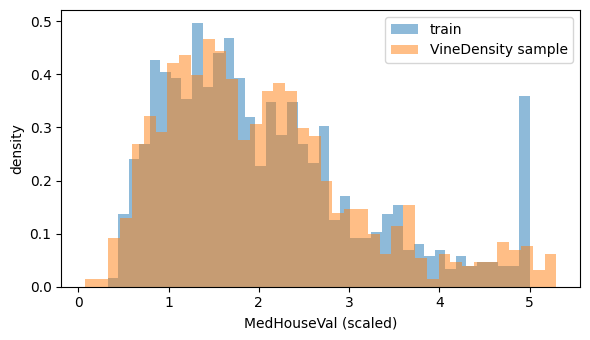

In [7]:
synth = dens.sample(n_samples=1000, seeds=[42])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(joint_train[:, -1], bins=40, alpha=0.5, density=True, label="train")
ax.hist(
  synth[:, -1], bins=40, alpha=0.5, density=True, label="VineDensity sample"
)
ax.set_xlabel("MedHouseVal (scaled)")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()

`cdf` is quasi-MC and so noisy at small `N`; bump `N` for tighter
estimates. Pass an explicit `seeds` for reproducibility. The joint CDF
is small at random points in 9D (each marginal contributes a factor
<= 1), so we evaluate at marginal quantiles to show the expected
monotone behaviour.

In [8]:
qs = np.linspace(0.1, 0.9, 5)
# Build points where every coordinate sits at the same marginal quantile.
grid = np.column_stack(
  [np.quantile(joint_train[:, j], qs) for j in range(joint_train.shape[1])]
)
cdf_grid = dens.cdf(grid, N=20000, seeds=[0])

print(f"{'marginal quantile':>18}  {'joint CDF':>10}")
for q_lvl, F_val in zip(qs, cdf_grid):
  print(f"{q_lvl:>18.2f}  {F_val:>10.4f}")

 marginal quantile   joint CDF
              0.10      0.0000
              0.30      0.0000
              0.50      0.0001
              0.70      0.0273
              0.90      0.4228


## What's next

- For ensembles of these single-vine estimators with model-confidence-set
  selection, see `09_sklearn_forest.ipynb`.
- For low-level control beyond what the sklearn wrappers expose (custom
  `FitControlsVinecop`, hand-crafted `RVineStructure`, raw `Vinecop.pdf`
  on pseudo-observations), reach for `pyvinecopulib.core` directly.